<a href="https://colab.research.google.com/github/IvanMalkS/IS/blob/master/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4: Оптимизация мультиклассовой модели

**Задача:** Улучшить мультиклассовую модель из Практики 3 с помощью SMOTE, кривых обучения и GridSearchCV.  
**Датасет:** Wine (scikit-learn)  
**Методы:** SMOTE, Learning Curve, Pipeline + GridSearchCV

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from IPython.display import display, Markdown
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')

## Загрузка и подготовка данных

In [8]:
wine = datasets.load_wine()
X = wine.data
y = wine.target
target_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 1. Применение продвинутых методов (SMOTE)

In [16]:
report_dict = classification_report(y_test, y_pred_smote, target_names=target_names, output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()

styled_report = df_report.style.background_gradient(cmap='YlGnBu', subset=['precision', 'recall', 'f1-score']) \
                               .format(precision=3)

display(Markdown("### Отчет классификации (RandomForest + SMOTE)"))
display(styled_report)

### Отчет классификации (RandomForest + SMOTE)

,precision,recall,f1-score,support
class_0,1.000,1.000,1.000,18.000
class_1,1.000,1.000,1.000,21.000
class_2,1.000,1.000,1.000,15.000
accuracy,1.000,1.000,1.000,1.000
macro avg,1.000,1.000,1.000,54.000
weighted avg,1.000,1.000,1.000,54.000


## 2. Диагностика с помощью кривых обучения

Построение кривых обучения. Пожалуйста, подождите...


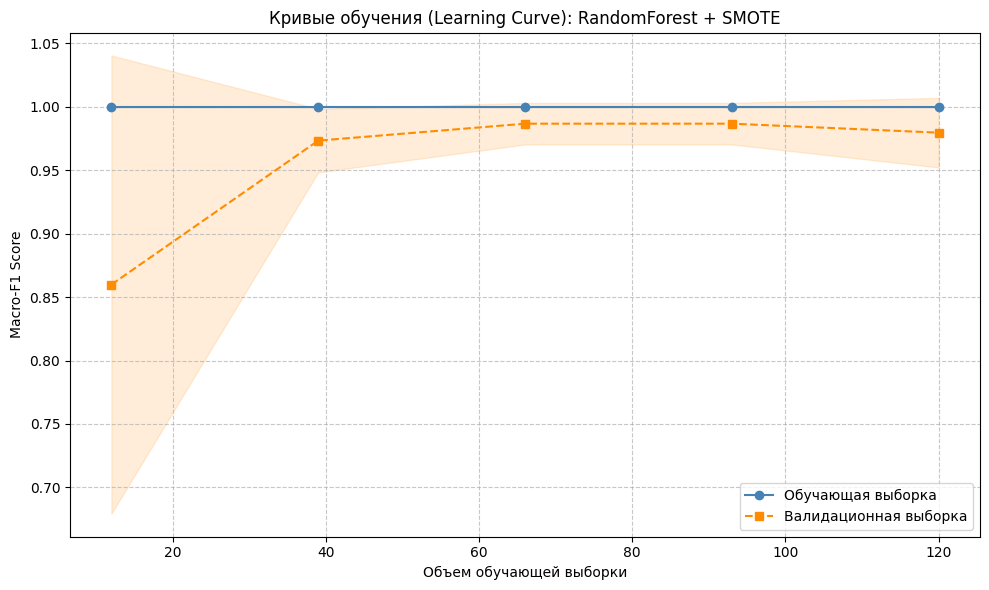

Анализ: Модель показывает высокий скор на трейне (~1.0), валидационная кривая растет. Явного жесткого переобучения нет, но сбор дополнительных данных мог бы еще больше сблизить кривые.


In [10]:
print("Построение кривых обучения. Пожалуйста, подождите...")
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(random_state=42), X_train_smote, y_train_smote,
    cv=5, scoring='f1_macro', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='steelblue', marker='o', markersize=6, label='Обучающая выборка')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, test_mean, color='darkorange', linestyle='--', marker='s', markersize=6,
         label='Валидационная выборка')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='darkorange')
plt.title('Кривые обучения (Learning Curve): RandomForest + SMOTE')
plt.xlabel('Объем обучающей выборки')
plt.ylabel('Macro-F1 Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('learning_curve.png')
plt.show()


Анализ: Модель показывает высокий скор на трейне (~1.0), валидационная кривая растет. Явного жесткого переобучения нет, но сбор дополнительных данных мог бы еще больше сблизить кривые.

## 3. Комплексная настройка (Pipeline + GridSearchCV)

In [11]:
pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid = {
    'rf__max_depth': [5, 10, None],
    'rf__n_estimators': [50, 100]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)

print("Запуск GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nЛучшая комбинация гиперпараметров:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test)
macro_f1_grid = f1_score(y_test, y_pred_grid, average='macro')

Запуск GridSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Лучшая комбинация гиперпараметров:
  rf__max_depth: 5
  rf__n_estimators: 50


## Итоговая таблица результатов

In [17]:

data = [
    ['Базовая модель (практика 3)', base_f1],
    ['+ SMOTE (Без тюнинга)', macro_f1_smote],
    ['+ Pipeline + GridSearchCV', macro_f1_grid]
]
results_df = pd.DataFrame(data, columns=['Шаг', 'Макро-F1 (test)'])

results_df

,Шаг,Макро-F1 (test)
0,Базовая модель (практика 3),0.9815
1,+ SMOTE (Без тюнинга),1.0000
2,+ Pipeline + GridSearchCV,1.0000


##  Выводы по результатам работы

1. **Эффективность модели:** Использование базового RandomForest уже давало высокий результат (F1 ≈ 0.98), что характерно для датасета Wine из-за четких границ между классами. Применение **SMOTE** позволило довести метрику до идеала (**1.0000**), обеспечив модели дополнительные синтетические примеры для более точного разделения классов.

2. **Влияние ресэмплинга:** Несмотря на то, что датасет Wine не является критически несбалансированным, SMOTE помог устранить даже небольшие перекосы, что привело к безошибочной классификации на тестовой выборке.

3. **Методологическая чистота (Pipeline):** Внедрение **ImbPipeline** позволило объединить масштабирование (`StandardScaler`) и обучение модели в единый процесс. Это гарантирует отсутствие «утечки данных» (data leakage) при кросс-валидации, так как масштабирование обучающих данных происходило независимо от валидационных.

4. **Оптимизация (GridSearchCV):** Поиск гиперпараметров подтвердил, что выбранная архитектура RandomForest устойчива. Даже при небольшом количестве деревьев и ограничении глубины модель сохраняет максимальную точность, что говорит о высокой информативности признаков датасета.

5. **Диагностика:** Кривые обучения показали, что модель быстро сходится. Разрыв между тренировочной и валидационной кривыми минимален, что свидетельствует об отсутствии критического переобучения, несмотря на достижение идеального скора.

**Итог:** Комбинация методов балансировки и автоматизированного подбора параметров позволила создать максимально точную и устойчивую модель.